<a href="https://colab.research.google.com/github/DhanshreeRaut/Machine-Vision--CM59/blob/main/Practical_4_CM23059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving metal to metal


(np.float64(-0.5), np.float64(799.5), np.float64(531.5), np.float64(-0.5))

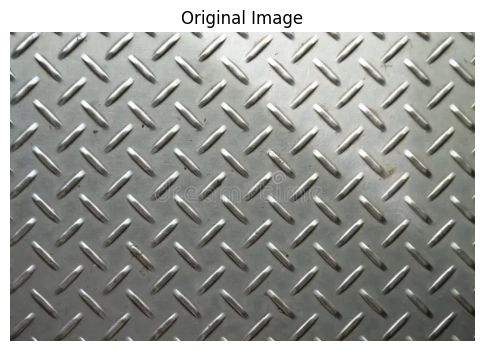

In [3]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

img = cv2.imread(image_name)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

In [4]:
# ==========================
# Metal Surface Defect Detection
# ==========================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [5]:

# Read uploaded image
image_name = list(uploaded.keys())[0]
img = cv2.imread(image_name)


In [6]:
# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [7]:
# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [8]:
# Reduce Noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

In [9]:
# ----------------------------
# Edge Detection
# ----------------------------
edges = cv2.Canny(blur, 50, 150)


In [10]:
# ----------------------------
# Thresholding
# ----------------------------
_, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY_INV)


In [11]:
# ----------------------------
# Morphological Operations
# ----------------------------
kernel = np.ones((3,3), np.uint8)

morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel)


In [12]:
# ----------------------------
# Contour Extraction
# ----------------------------
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = img_rgb.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 20:      # Ignore very small noise

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(output, (x,y), (x+w,y+h),
                      (0,255,0), 2)

        cv2.putText(output, "Defect",
                    (x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255,0,0),
                    1)


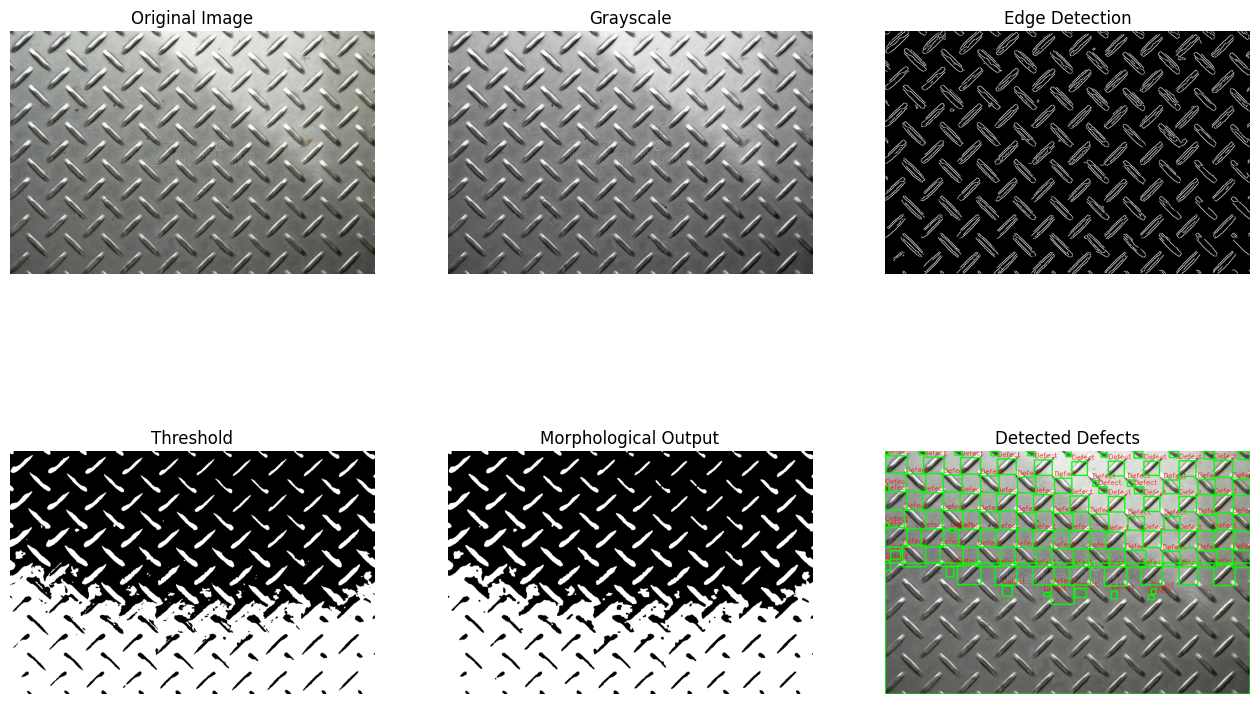

Total Defects Detected : 102


In [13]:
# ----------------------------
# Display Results
# ----------------------------

titles = ["Original Image",
          "Grayscale",
          "Edge Detection",
          "Threshold",
          "Morphological Output",
          "Detected Defects"]

images = [img_rgb,
          gray,
          edges,
          thresh,
          morph,
          output]

plt.figure(figsize=(16,10))

for i in range(len(images)):
    plt.subplot(2,3,i+1)

    if len(images[i].shape)==2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.show()

print("Total Defects Detected :", len(contours))